In [ ]:
!pip install pytorch-pretrained-biggan
#import all necessary libraries
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pytorch_pretrained_biggan import BigGAN, truncated_noise_sample, one_hot_from_int
from torchvision.utils import save_image

# GAN-generated images are saved to Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

DATASET_DIR = "/content/drive/MyDrive/Dissertation/cifake_dataset"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BigGAN.from_pretrained("biggan-deep-256").to(DEVICE).eval()

N_SAMPLES = 5000
BATCH_SIZE = 32
TRUNCATION = 0.4

# Generate images in the cifake_dataset/GAN folder on Drive.
OUTPUT_DIR = os.path.join(DATASET_DIR, "GAN")
os.makedirs(OUTPUT_DIR, exist_ok=True)

generated = 0
with torch.no_grad():
    while generated < N_SAMPLES:
        batch = min(BATCH_SIZE, N_SAMPLES - generated)
        noise  = truncated_noise_sample(truncation=TRUNCATION, batch_size=batch)
        labels = one_hot_from_int(
            [i % 1000 for i in range(generated, generated + batch)], batch_size=batch
        )
        noise  = torch.tensor(noise, dtype=torch.float32, device=DEVICE)
        labels = torch.tensor(labels, dtype=torch.float32, device=DEVICE)

        imgs = model(noise, labels, TRUNCATION)
        imgs = (imgs + 1) / 2  # [-1,1] -> [0,1]

        # Downsample images to match CIFAKE images which are 32x32
        imgs = F.interpolate(imgs, size=(32, 32), mode="bilinear", align_corners=False)

        for i, img in enumerate(imgs):
            save_image(img, os.path.join(OUTPUT_DIR, f"gan_fake_{generated + i:05d}.jpg"))
        generated += batch

print(f"Done — {N_SAMPLES} images saved directly to {OUTPUT_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 9.5 MB/s eta 0:00:00
Mounted at /content/drive


100%|██████████| 715/715 [00:00<00:00, 431004.22B/s]


Done — 5000 images saved directly to /content/drive/MyDrive/Dissertation/cifake_dataset/GAN


Done — 10000 images saved directly to /content/drive/MyDrive/Dissertation/cifake_dataset/GAN


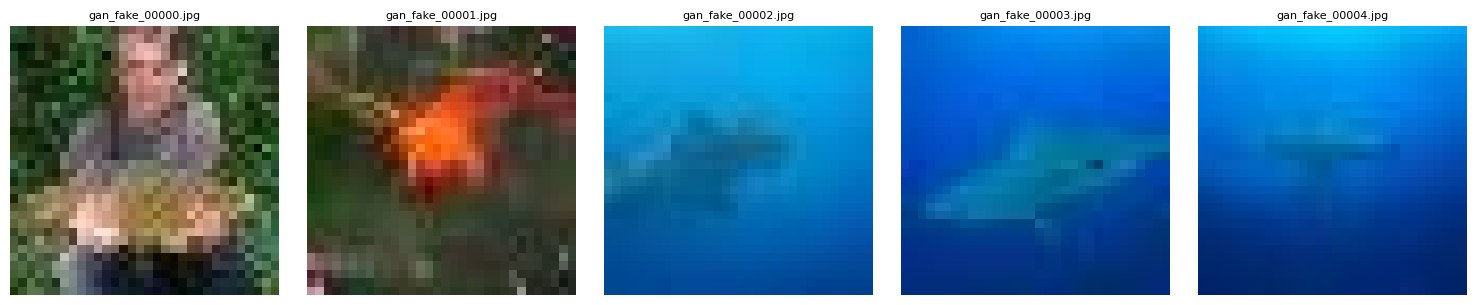

Total FAKE-class images now in /content/drive/MyDrive/Dissertation/cifake_dataset/GAN: 10000


In [2]:
N_SAMPLES = 10000
generated = 5000
with torch.no_grad():
    while generated < N_SAMPLES:
        batch = min(BATCH_SIZE, N_SAMPLES - generated)
        noise  = truncated_noise_sample(truncation=TRUNCATION, batch_size=batch)
        labels = one_hot_from_int(
            [i % 1000 for i in range(generated, generated + batch)], batch_size=batch
        )
        noise  = torch.tensor(noise, dtype=torch.float32, device=DEVICE)
        labels = torch.tensor(labels, dtype=torch.float32, device=DEVICE)


        imgs = model(noise, labels, TRUNCATION)
        imgs = (imgs + 1) / 2
        imgs = F.interpolate(imgs, size=(32, 32), mode="bilinear", align_corners=False)


        for i, img in enumerate(imgs):
            save_image(img, os.path.join(OUTPUT_DIR, f"gan_fake_{generated + i:05d}.jpg"))
        generated += batch


print(f"Done — {N_SAMPLES} images saved directly to {OUTPUT_DIR}")


# Display 5 generated samples
NUM_PREVIEW = 5
gan_files = sorted(f for f in os.listdir(OUTPUT_DIR) if f.startswith("gan_fake_"))
preview_files = gan_files[:NUM_PREVIEW]

fig, axes = plt.subplots(1, NUM_PREVIEW, figsize=(3 * NUM_PREVIEW, 3))
for ax, filename in zip(axes, preview_files):
    img = plt.imread(os.path.join(OUTPUT_DIR, filename))
    ax.imshow(img)
    ax.set_title(filename, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Total FAKE-class images now in {OUTPUT_DIR}: {len(os.listdir(OUTPUT_DIR))}")